In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from transformers import AutoTokenizer, AutoConfig, AutoModel, TrainingArguments, EarlyStoppingCallback, set_seed
from datasets import Dataset, DatasetDict
from peft import LoraConfig, get_peft_model, TaskType
from dataclasses import dataclass
from sklearn.metrics import mean_absolute_error, cohen_kappa_score
from typing import Optional, Dict, Any, List
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import re
import math
import os

In [ ]:
MODEL_NAME = "Qwen/Qwen2.5-3B-Instruct"
TRAIN_CSV = "/content/ielts_train_df.csv"
VAL_CSV   = "/content/ielts_val_df.csv"
TEST_CSV  = "/content/ielts_test_df.csv"

MAX_LENGTH = 1024
SEED = 42

BATCH_SIZE = 1
GRAD_ACCUM = 7

LR = 5e-5
EPOCHS = 5
WEIGHT_DECAY = 0.01
OUTPUT_DIR = "./qwen25_3b_ielts_4criteria"

TARGET_COLS = ["TR", "CC", "LR", "GRA"]

# 11 band levels: 4.0 -> 9.0 step 0.5
NUM_BINS = 11
NUM_THRESHOLDS = NUM_BINS - 1   # 10

SCORE_MIN = 4.0
SCORE_MAX = 9.0
SCORE_STEP = 0.5

set_seed(SEED)

TR_FEATURE_COLS = [
    "tr_prompt_essay_sim",
    "tr_prompt_keyword_coverage",
    "tr_has_opinion",
    "tr_has_both_views",
    "tr_has_example",
    "tr_has_conclusion",
    "tr_word_count",
]

CC_FEATURE_COLS = [
    "cc_num_paragraphs",
    "cc_avg_paragraph_len",
    "cc_avg_sentence_len",
    "cc_sentence_len_std",
    "cc_discourse_marker_count",
    "cc_discourse_marker_diversity",
]

LR_FEATURE_COLS = [
    "lr_root_ttr",
    "lr_avg_word_len",
    "lr_long_word_ratio",
    "lr_repetition_ratio",
    "lr_unique_word_ratio",
    "lr_lexical_density_proxy",
]

GRA_FEATURE_COLS = [
    "gf_word_count",
    "gf_sentence_count",
    "gf_avg_sentence_len",
    "gf_short_sentence_ratio",
    "gf_long_sentence_ratio",
    "gf_punct_density",
    "gf_repeated_punct_ratio",
    "gf_lowercase_sent_start_ratio",
    "gf_lowercase_i_ratio",
    "gf_repeated_word_ratio",
    "gf_missing_terminal_punct",
]

CRITERION_WEIGHTS = [1.0, 1.0, 1.0, 1.0]
HEAD_DROPOUT = 0.1
BIAS_LOSS_WEIGHT = 0.02
ORDINAL_LOSS_NAME = "bce_with_logits"

In [ ]:
def simple_words(text):
    return re.findall(r"\b[\w']+\b", str(text).lower())

def simple_sentences(text):
    sents = [s.strip() for s in re.split(r"[.!?]+", str(text)) if s.strip()]
    return sents if sents else [str(text).strip()]

def extract_grammar_features(text: str):
    text = str(text).strip()

    words = re.findall(r"\b[\w']+\b", text)
    word_count = max(len(words), 1)

    sentence_candidates = re.split(r"[.!?]+", text)
    sentences = [s.strip() for s in sentence_candidates if s.strip()]
    sentence_count = max(len(sentences), 1)

    avg_sentence_len = word_count / sentence_count

    sent_word_counts = []
    for s in sentences:
        sw = re.findall(r"\b[\w']+\b", s)
        sent_word_counts.append(len(sw))
    if len(sent_word_counts) == 0:
        sent_word_counts = [word_count]

    short_sentence_ratio = np.mean([c < 8 for c in sent_word_counts])
    long_sentence_ratio = np.mean([c > 25 for c in sent_word_counts])

    punct_count = len(re.findall(r"[,:;()\-\"]", text))
    punct_density = punct_count / word_count

    repeated_punct_count = len(re.findall(r"([!?.,;:])\1+", text))
    repeated_punct_ratio = repeated_punct_count / sentence_count

    lowercase_sent_starts = 0
    for s in sentences:
        s = s.strip()
        if len(s) > 0 and s[0].islower():
            lowercase_sent_starts += 1
    lowercase_sent_start_ratio = lowercase_sent_starts / sentence_count

    lowercase_i_count = len(re.findall(r"\bi\b", text))
    lowercase_i_ratio = lowercase_i_count / word_count

    repeated_word_count = 0
    lower_words = [w.lower() for w in words]
    for i in range(1, len(lower_words)):
        if lower_words[i] == lower_words[i - 1]:
            repeated_word_count += 1
    repeated_word_ratio = repeated_word_count / word_count

    missing_terminal_punct = 0.0 if re.search(r"[.!?]\s*$", text) else 1.0

    return [
        float(word_count),
        float(sentence_count),
        float(avg_sentence_len),
        float(short_sentence_ratio),
        float(long_sentence_ratio),
        float(punct_density),
        float(repeated_punct_ratio),
        float(lowercase_sent_start_ratio),
        float(lowercase_i_ratio),
        float(repeated_word_ratio),
        float(missing_terminal_punct),
    ]


DISCOURSE_MARKERS = [
    "however", "therefore", "moreover", "furthermore", "in addition",
    "for example", "for instance", "on the other hand", "in conclusion",
    "to conclude", "as a result", "first", "second", "finally"
]

def extract_cc_features(text: str):
    text = str(text).strip()
    paragraphs = [p.strip() for p in text.split("\n") if p.strip()]
    if not paragraphs:
        paragraphs = [text]

    sentences = simple_sentences(text)
    sent_lens = [len(simple_words(s)) for s in sentences]
    sent_lens = sent_lens if sent_lens else [1]

    para_lens = [len(simple_words(p)) for p in paragraphs]

    text_lower = text.lower()
    marker_counts = [text_lower.count(m) for m in DISCOURSE_MARKERS]

    return [
        float(len(paragraphs)),
        float(np.mean(para_lens) if para_lens else 0.0),
        float(np.mean(sent_lens)),
        float(np.std(sent_lens)),
        float(sum(marker_counts)),
        float(sum(c > 0 for c in marker_counts)),
    ]


def extract_lr_features(text: str):
    words = simple_words(text)
    word_count = max(len(words), 1)
    unique_words = len(set(words))

    root_ttr = unique_words / np.sqrt(word_count)
    avg_word_len = np.mean([len(w) for w in words]) if words else 0.0
    long_word_ratio = np.mean([len(w) >= 7 for w in words]) if words else 0.0

    repeated = 0
    for i in range(1, len(words)):
        if words[i] == words[i - 1]:
            repeated += 1
    repetition_ratio = repeated / word_count
    unique_word_ratio = unique_words / word_count

    lexical_density_proxy = np.mean([len(w) > 3 for w in words]) if words else 0.0

    return [
        float(root_ttr),
        float(avg_word_len),
        float(long_word_ratio),
        float(repetition_ratio),
        float(unique_word_ratio),
        float(lexical_density_proxy),
    ]


def extract_tr_features(prompt: str, essay: str):
    prompt = str(prompt).lower().strip()
    essay = str(essay).lower().strip()

    prompt_words = set(simple_words(prompt))
    essay_words = set(simple_words(essay))

    keyword_coverage = len(prompt_words & essay_words) / max(len(prompt_words), 1)
    prompt_essay_sim = keyword_coverage

    opinion_markers = ["i believe", "i think", "in my opinion", "from my perspective", "i agree", "i disagree"]
    both_views_markers = ["on the one hand", "on the other hand", "both views"]
    example_markers = ["for example", "for instance", "such as"]
    conclusion_markers = ["in conclusion", "to conclude", "to sum up"]

    has_opinion = float(any(m in essay for m in opinion_markers))
    has_both_views = float(any(m in essay for m in both_views_markers))
    has_example = float(any(m in essay for m in example_markers))
    has_conclusion = float(any(m in essay for m in conclusion_markers))
    word_count = len(simple_words(essay))

    return [
        float(prompt_essay_sim),
        float(keyword_coverage),
        float(has_opinion),
        float(has_both_views),
        float(has_example),
        float(has_conclusion),
        float(word_count),
    ]

In [ ]:
# 1. Load dữ liệu gốc
train_df = pd.read_csv(TRAIN_CSV, engine="python", on_bad_lines="skip")
val_df = pd.read_csv(VAL_CSV, engine="python", on_bad_lines="skip") if os.path.exists(VAL_CSV) else None
test_df = pd.read_csv(TEST_CSV, engine="python", on_bad_lines="skip") if os.path.exists(TEST_CSV) else None

# 2. Tách tập validation nếu chưa có
if val_df is None:
    from sklearn.model_selection import train_test_split
    train_df, val_df = train_test_split(train_df, test_size=0.1, random_state=SEED)

needed_cols = ["prompt", "essay"] + TARGET_COLS

def robust_clean_df(df):
    if df is None:
        return None

    df = df[needed_cols].copy()

    for col in TARGET_COLS:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df.dropna(subset=TARGET_COLS).reset_index(drop=True)

    df["prompt"] = df["prompt"].astype(str).str.strip()
    df["essay"] = df["essay"].astype(str).str.strip()

    df = df[(df["prompt"].str.len() > 0) & (df["essay"].str.len() > 20)].reset_index(drop=True)

    for col in TARGET_COLS:
        df[col] = df[col].clip(SCORE_MIN, SCORE_MAX)

    return df

train_df = robust_clean_df(train_df)
val_df = robust_clean_df(val_df)
test_df = robust_clean_df(test_df)

print(f"Train shape: {train_df.shape if train_df is not None else 0}")
print(f"Val shape: {val_df.shape if val_df is not None else 0}")
print(train_df[TARGET_COLS].head())

Train shape: (6618, 6)
Val shape: (827, 6)
    TR   CC   LR  GRA
0  6.0  6.0  6.0  6.0
1  6.5  6.5  6.5  6.5
2  7.0  7.0  7.0  7.0
3  5.0  5.0  5.0  5.0
4  4.5  4.5  4.5  4.5


In [ ]:
def build_input_text(row):
    prompt = str(row["prompt"]).strip()
    essay = str(row["essay"]).strip()
    return f"[PROMPT]\n{prompt}\n\n[ESSAY]\n{essay}"

train_df["text"] = train_df.apply(build_input_text, axis=1)
val_df["text"] = val_df.apply(build_input_text, axis=1)
if test_df is not None:
    test_df["text"] = test_df.apply(build_input_text, axis=1)


def standardize_features(train_feats, val_feats, test_feats=None):
    feat_mean = train_feats.mean(axis=0)
    feat_std = train_feats.std(axis=0)
    feat_std = np.where(feat_std < 1e-6, 1.0, feat_std)

    train_feats = (train_feats - feat_mean) / feat_std
    val_feats = (val_feats - feat_mean) / feat_std
    if test_feats is not None:
        test_feats = (test_feats - feat_mean) / feat_std

    return train_feats, val_feats, test_feats, feat_mean, feat_std


# ---- TR ----
train_tr_feats = np.array(
    [extract_tr_features(p, e) for p, e in zip(train_df["prompt"], train_df["essay"])],
    dtype=np.float32
)
val_tr_feats = np.array(
    [extract_tr_features(p, e) for p, e in zip(val_df["prompt"], val_df["essay"])],
    dtype=np.float32
)
test_tr_feats = None
if test_df is not None:
    test_tr_feats = np.array(
        [extract_tr_features(p, e) for p, e in zip(test_df["prompt"], test_df["essay"])],
        dtype=np.float32
    )

train_tr_feats, val_tr_feats, test_tr_feats, tr_feat_mean, tr_feat_std = standardize_features(
    train_tr_feats, val_tr_feats, test_tr_feats
)

# ---- CC ----
train_cc_feats = np.array([extract_cc_features(x) for x in train_df["essay"]], dtype=np.float32)
val_cc_feats = np.array([extract_cc_features(x) for x in val_df["essay"]], dtype=np.float32)
test_cc_feats = None
if test_df is not None:
    test_cc_feats = np.array([extract_cc_features(x) for x in test_df["essay"]], dtype=np.float32)

train_cc_feats, val_cc_feats, test_cc_feats, cc_feat_mean, cc_feat_std = standardize_features(
    train_cc_feats, val_cc_feats, test_cc_feats
)

# ---- LR ----
train_lr_feats = np.array([extract_lr_features(x) for x in train_df["essay"]], dtype=np.float32)
val_lr_feats = np.array([extract_lr_features(x) for x in val_df["essay"]], dtype=np.float32)
test_lr_feats = None
if test_df is not None:
    test_lr_feats = np.array([extract_lr_features(x) for x in test_df["essay"]], dtype=np.float32)

train_lr_feats, val_lr_feats, test_lr_feats, lr_feat_mean, lr_feat_std = standardize_features(
    train_lr_feats, val_lr_feats, test_lr_feats
)

# ---- GRA ----
train_gra_feats = np.array([extract_grammar_features(x) for x in train_df["essay"]], dtype=np.float32)
val_gra_feats = np.array([extract_grammar_features(x) for x in val_df["essay"]], dtype=np.float32)
test_gra_feats = None
if test_df is not None:
    test_gra_feats = np.array([extract_grammar_features(x) for x in test_df["essay"]], dtype=np.float32)

train_gra_feats, val_gra_feats, test_gra_feats, gra_feat_mean, gra_feat_std = standardize_features(
    train_gra_feats, val_gra_feats, test_gra_feats
)

# attach
train_df["tr_features"] = train_tr_feats.tolist()
train_df["cc_features"] = train_cc_feats.tolist()
train_df["lr_features"] = train_lr_feats.tolist()
train_df["gra_features"] = train_gra_feats.tolist()

val_df["tr_features"] = val_tr_feats.tolist()
val_df["cc_features"] = val_cc_feats.tolist()
val_df["lr_features"] = val_lr_feats.tolist()
val_df["gra_features"] = val_gra_feats.tolist()

if test_df is not None:
    test_df["tr_features"] = test_tr_feats.tolist()
    test_df["cc_features"] = test_cc_feats.tolist()
    test_df["lr_features"] = test_lr_feats.tolist()
    test_df["gra_features"] = test_gra_feats.tolist()

def make_labels(df):
    df = df.copy()
    df["labels"] = df[TARGET_COLS].astype(np.float32).values.tolist()
    return df

train_df = make_labels(train_df)
val_df = make_labels(val_df)
if test_df is not None:
    test_df = make_labels(test_df)

Num grammar features: 11
Example gra_features: [-0.6826593279838562, 0.1521308720111847, -0.42168086767196655, 0.9166474342346191, -0.8336414694786072, -1.6511703729629517, -0.08738477528095245, 10.569822311401367, -0.12364798039197922, -0.23104701936244965, -0.2283613085746765]


In [ ]:
train_ds = Dataset.from_pandas(
    train_df[["text", "labels", "tr_features", "cc_features", "lr_features", "gra_features"]],
    preserve_index=False
)

val_ds = Dataset.from_pandas(
    val_df[["text", "labels", "tr_features", "cc_features", "lr_features", "gra_features"]],
    preserve_index=False
)

dataset_dict = DatasetDict({
    "train": train_ds,
    "validation": val_ds,
})

if test_df is not None:
    test_ds = Dataset.from_pandas(
        test_df[["text", "labels", "tr_features", "cc_features", "lr_features", "gra_features"]],
        preserve_index=False
    )
    dataset_dict["test"] = test_ds

In [8]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "right"

def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False,
    )

tokenized_ds = dataset_dict.map(tokenize_fn, batched=True)
tokenized_ds = tokenized_ds.remove_columns(["text"])
tokenized_ds.set_format(type="torch")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/6618 [00:00<?, ? examples/s]

Map:   0%|          | 0/827 [00:00<?, ? examples/s]

Map:   0%|          | 0/828 [00:00<?, ? examples/s]

In [ ]:
class QwenForIELTSMultiTaskOrdinal(nn.Module):
    def __init__(self, model_name: str, tokenizer, head_dropout: float = 0.1):
        super().__init__()
        self.config = AutoConfig.from_pretrained(model_name)
        self.config.pad_token_id = tokenizer.pad_token_id

        self.backbone = AutoModel.from_pretrained(
            model_name,
            torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
        )
        self.backbone.config.pad_token_id = tokenizer.pad_token_id
        self.backbone.config.use_cache = False

        lora_config = LoraConfig(
            task_type=TaskType.FEATURE_EXTRACTION,
            r=8,
            lora_alpha=16,
            lora_dropout=0.1,
            bias="none",
            target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
        )
        self.backbone = get_peft_model(self.backbone, lora_config)

        hidden_size = self.backbone.config.hidden_size
        self.dropout = nn.Dropout(head_dropout)

        self.tr_feat_dim = len(TR_FEATURE_COLS)
        self.cc_feat_dim = len(CC_FEATURE_COLS)
        self.lr_feat_dim = len(LR_FEATURE_COLS)
        self.gra_feat_dim = len(GRA_FEATURE_COLS)

        self.tr_mlp = nn.Sequential(
            nn.Linear(hidden_size + self.tr_feat_dim, 256),
            nn.GELU(),
            nn.Dropout(head_dropout),
            nn.Linear(256, NUM_THRESHOLDS),
        )
        self.cc_mlp = nn.Sequential(
            nn.Linear(hidden_size + self.cc_feat_dim, 256),
            nn.GELU(),
            nn.Dropout(head_dropout),
            nn.Linear(256, NUM_THRESHOLDS),
        )
        self.lr_mlp = nn.Sequential(
            nn.Linear(hidden_size + self.lr_feat_dim, 256),
            nn.GELU(),
            nn.Dropout(head_dropout),
            nn.Linear(256, NUM_THRESHOLDS),
        )
        self.gra_mlp = nn.Sequential(
            nn.Linear(hidden_size + self.gra_feat_dim, 256),
            nn.GELU(),
            nn.Dropout(head_dropout),
            nn.Linear(256, NUM_THRESHOLDS),
        )

    def _last_token_pool(self, hidden_states, attention_mask):
        last_token_idx = attention_mask.sum(dim=1) - 1
        last_token_idx = last_token_idx.clamp(min=0)
        batch_idx = torch.arange(hidden_states.size(0), device=hidden_states.device)
        pooled = hidden_states[batch_idx, last_token_idx]
        return pooled

    def forward(
        self,
        input_ids=None,
        attention_mask=None,
        tr_features=None,
        cc_features=None,
        lr_features=None,
        gra_features=None,
        labels=None,
        **kwargs
    ):
        outputs = self.backbone(
            input_ids=input_ids,
            attention_mask=attention_mask,
            **kwargs,
        )

        hidden_states = outputs.last_hidden_state
        pooled = self._last_token_pool(hidden_states, attention_mask)
        pooled = self.dropout(pooled)

        if tr_features is None or cc_features is None or lr_features is None or gra_features is None:
            raise ValueError("tr_features, cc_features, lr_features, gra_features are all required")

        tr_features = tr_features.to(device=pooled.device, dtype=pooled.dtype)
        cc_features = cc_features.to(device=pooled.device, dtype=pooled.dtype)
        lr_features = lr_features.to(device=pooled.device, dtype=pooled.dtype)
        gra_features = gra_features.to(device=pooled.device, dtype=pooled.dtype)

        tr_logits = self.tr_mlp(torch.cat([pooled, tr_features], dim=1))   # [B, 10]
        cc_logits = self.cc_mlp(torch.cat([pooled, cc_features], dim=1))
        lr_logits = self.lr_mlp(torch.cat([pooled, lr_features], dim=1))
        gra_logits = self.gra_mlp(torch.cat([pooled, gra_features], dim=1))

        logits = torch.stack([tr_logits, cc_logits, lr_logits, gra_logits], dim=1)  # [B, 4, 10]

        return {
            "logits": logits,
            "ordinal_logits": logits,
        }

model = QwenForIELTSMultiTaskOrdinal(MODEL_NAME, tokenizer, head_dropout=HEAD_DROPOUT)
model.backbone.print_trainable_parameters()
print("Ordinal heads are trainable by default.")

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

trainable params: 3,686,400 || all params: 3,089,625,088 || trainable%: 0.1193
Heads are trainable by default.


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import Trainer

def scores_to_class_indices(labels):
    labels = torch.clamp(labels, SCORE_MIN, SCORE_MAX)
    return torch.round((labels - SCORE_MIN) / SCORE_STEP).long()

def class_indices_to_ordinal_targets(class_indices, num_thresholds):
    # class_indices: [B, 4]
    thresholds = torch.arange(num_thresholds, device=class_indices.device).view(1, 1, -1)
    targets = (class_indices.unsqueeze(-1) > thresholds).float()
    return targets   # [B, 4, 10]

def ordinal_logits_to_scores_torch(logits):
    probs = torch.sigmoid(logits)
    pred_class = (probs > 0.5).sum(dim=-1).float()
    return SCORE_MIN + pred_class * SCORE_STEP

def ordinal_logits_to_scores_np(logits):
    probs = 1.0 / (1.0 + np.exp(-logits))
    pred_class = (probs > 0.5).sum(axis=-1).astype(np.float32)
    return SCORE_MIN + pred_class * SCORE_STEP

class IELTSOrdinalMultiTaskTrainer(Trainer):
    def __init__(
        self,
        *args,
        criterion_weights=None,
        bias_loss_weight=0.02,
        **kwargs
    ):
        super().__init__(*args, **kwargs)

        if criterion_weights is None:
            criterion_weights = [1.0, 1.0, 1.0, 1.0]

        self.criterion_weights = torch.tensor(criterion_weights, dtype=torch.float32)
        self.bias_loss_weight = bias_loss_weight
        self.ordinal_loss_fn = nn.BCEWithLogitsLoss(reduction="none")

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")   # [B, 4], raw scores
        outputs = model(**inputs)
        logits = outputs["logits"]      # [B, 4, 10]

        labels = labels.to(logits.device).to(torch.float32)
        class_indices = scores_to_class_indices(labels)
        ordinal_targets = class_indices_to_ordinal_targets(class_indices, NUM_THRESHOLDS).to(logits.dtype)

        per_threshold_loss = self.ordinal_loss_fn(logits, ordinal_targets)   # [B, 4, 10]
        per_dim_loss = per_threshold_loss.mean(dim=-1)                       # [B, 4]

        weights = self.criterion_weights.to(device=logits.device, dtype=logits.dtype).view(1, -1)
        weighted_loss = (per_dim_loss * weights).sum() / (
            weights.sum().clamp_min(1e-8) * logits.size(0)
        )

        pred_scores = ordinal_logits_to_scores_torch(logits)
        pred_mean = pred_scores.mean(dim=0)
        label_mean = labels.mean(dim=0)
        bias_loss = torch.abs(pred_mean - label_mean).mean()

        loss = weighted_loss + self.bias_loss_weight * bias_loss
        return (loss, outputs) if return_outputs else loss

In [ ]:
@dataclass
class OrdinalCollator:
    tokenizer: Any

    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        labels = torch.stack([
            f["labels"] if isinstance(f["labels"], torch.Tensor)
            else torch.tensor(f["labels"], dtype=torch.float)
            for f in features
        ]).float()

        tr_features = torch.stack([
            f["tr_features"] if isinstance(f["tr_features"], torch.Tensor)
            else torch.tensor(f["tr_features"], dtype=torch.float)
            for f in features
        ]).float()

        cc_features = torch.stack([
            f["cc_features"] if isinstance(f["cc_features"], torch.Tensor)
            else torch.tensor(f["cc_features"], dtype=torch.float)
            for f in features
        ]).float()

        lr_features = torch.stack([
            f["lr_features"] if isinstance(f["lr_features"], torch.Tensor)
            else torch.tensor(f["lr_features"], dtype=torch.float)
            for f in features
        ]).float()

        gra_features = torch.stack([
            f["gra_features"] if isinstance(f["gra_features"], torch.Tensor)
            else torch.tensor(f["gra_features"], dtype=torch.float)
            for f in features
        ]).float()

        batch = self.tokenizer.pad(
            [
                {
                    k: v for k, v in f.items()
                    if k not in ["labels", "tr_features", "cc_features", "lr_features", "gra_features"]
                }
                for f in features
            ],
            padding=True,
            return_tensors="pt"
        )

        batch["labels"] = labels
        batch["tr_features"] = tr_features
        batch["cc_features"] = cc_features
        batch["lr_features"] = lr_features
        batch["gra_features"] = gra_features
        return batch

data_collator = OrdinalCollator(tokenizer)

In [ ]:
def round_to_half(x):
    return np.round(x * 2) / 2

def compute_metrics(eval_pred):
    preds, labels = eval_pred
    if isinstance(preds, tuple):
        preds = preds[0]

    preds = np.asarray(preds, dtype=np.float32)   # [B, 4, 10]
    labels = np.asarray(labels, dtype=np.float32) # [B, 4]

    pred_scores = ordinal_logits_to_scores_np(preds)
    pred_scores = np.clip(pred_scores, SCORE_MIN, SCORE_MAX)
    labels = np.clip(labels, SCORE_MIN, SCORE_MAX)

    preds_half = round_to_half(pred_scores)

    maes = []
    qwks = []

    for i in range(labels.shape[1]):
        maes.append(mean_absolute_error(labels[:, i], preds_half[:, i]))

        y_true = np.round((labels[:, i] - SCORE_MIN) / SCORE_STEP).astype(int)
        y_pred = np.round((preds_half[:, i] - SCORE_MIN) / SCORE_STEP).astype(int)

        qwks.append(cohen_kappa_score(y_true, y_pred, weights="quadratic"))

    within_05 = np.mean(np.abs(preds_half - labels) <= 0.5)

    return {
        "mean_mae": float(np.mean(maes)),
        "mean_qwk": float(np.mean(qwks)),
        "tr_qwk": float(qwks[0]),
        "cc_qwk": float(qwks[1]),
        "lr_qwk": float(qwks[2]),
        "gra_qwk": float(qwks[3]),
        "within_0.5_acc": float(within_05),
    }

In [13]:
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=20,

    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,

    learning_rate=LR,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    warmup_ratio=0.1,

    load_best_model_at_end=True,
    metric_for_best_model="mean_qwk",
    greater_is_better=True,

    bf16=True,
    fp16=False,

    gradient_checkpointing=False,
    remove_unused_columns=False,
    report_to="none",
    save_total_limit=2,
    max_grad_norm=1.0,
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [14]:
from transformers import get_cosine_schedule_with_warmup

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

num_update_steps_per_epoch = max(
    1, math.ceil(len(tokenized_ds["train"]) / (BATCH_SIZE * GRAD_ACCUM))
)

num_training_steps = num_update_steps_per_epoch * EPOCHS

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(num_training_steps * 0.1),
    num_training_steps=num_training_steps
)

In [ ]:
trainer = IELTSOrdinalMultiTaskTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["validation"],
    data_collator=data_collator,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    optimizers=(optimizer, scheduler),
    criterion_weights=CRITERION_WEIGHTS,
    bias_loss_weight=BIAS_LOSS_WEIGHT,
)

In [ ]:
from torch.utils.data import DataLoader

debug_loader = DataLoader(
    tokenized_ds["train"],
    batch_size=2,
    collate_fn=data_collator
)

batch = next(iter(debug_loader))
print(batch.keys())
print(batch["labels"])
print(batch["labels"].shape)
print(batch["labels"].dtype)
batch = next(iter(debug_loader))
for k, v in batch.items():
    print(k, v.shape if hasattr(v, "shape") else type(v))
with torch.no_grad():
    outputs = model(
        input_ids=batch["input_ids"].to(model.backbone.device),
        attention_mask=batch["attention_mask"].to(model.backbone.device),
        tr_features=batch["tr_features"].to(model.backbone.device),
        cc_features=batch["cc_features"].to(model.backbone.device),
        lr_features=batch["lr_features"].to(model.backbone.device),
        gra_features=batch["gra_features"].to(model.backbone.device),
    )
print(outputs["logits"].shape)

KeysView({'input_ids': tensor([[ 42347,   3361,   2828,    921,   8441,   5837,    525,  10164,    264,
           6765,   3311,    315,   3220,    389,  12613,    862,  27550,    311,
           1896,    949,    304,   1045,  15245,   9833,  42582,     13,  25028,
          17585,    429,    432,   1035,    387,   2664,    421,   1493,   5837,
            646,   8329,    279,   3220,    389,   2841,    311,   1896,    949,
            304,   9833,     13,   2014,   1128,  12818,    653,    498,   7503,
            476,  28295,   1939,     58,   9996,   3022,    921,   3862,    525,
           2696,    315,   5837,    304,    279,   1879,    879,    525,   1667,
           2244,   3311,    315,   3220,    389,  42649,    315,    862,   7263,
             13,    358,   7503,    429,    807,   1265,   1191,  10164,   3220,
            389,   2841,  10552,   7488,    304,    429,   1616,    807,    686,
           1191,    279,  50375,    315,   4124,  17628,    304,    862,   2272,
     

In [17]:
trainer.train()

Epoch,Training Loss,Validation Loss,Mean Mae,Mean Qwk,Tr Qwk,Cc Qwk,Lr Qwk,Gra Qwk,Within 0.5 Acc
1,8.749036,1.277021,0.881802,0.430151,0.432230,0.427290,0.464123,0.396961,0.498791
2,9.234254,1.144605,0.828144,0.541960,0.553582,0.542217,0.552165,0.519876,0.529927
3,7.417770,1.170739,0.824365,0.552767,0.556335,0.546983,0.576578,0.531173,0.546252
4,6.449635,1.092429,0.798519,0.580214,0.585196,0.577438,0.600125,0.558097,0.542322
5,6.561119,1.097041,0.798216,0.589637,0.592865,0.589671,0.605479,0.570534,0.550181


TrainOutput(global_step=4730, training_loss=14.382524710528191, metrics={'train_runtime': 7799.0422, 'train_samples_per_second': 4.243, 'train_steps_per_second': 0.606, 'total_flos': 0.0, 'train_loss': 14.382524710528191, 'epoch': 5.0})

     epoch  eval_loss  eval_mean_qwk  eval_gra_qwk  eval_within_0.5_acc
47     1.0   1.277021       0.430151      0.396961             0.498791
95     2.0   1.144605       0.541960      0.519876             0.529927
143    3.0   1.170739       0.552767      0.531173             0.546252
192    4.0   1.092429       0.580214      0.558097             0.542322
240    5.0   1.097041       0.589637      0.570534             0.550181
288    6.0   1.102714       0.588651      0.570945             0.546856
337    7.0   1.137364       0.578469      0.556595             0.540206
385    8.0   1.138637       0.568172      0.542467             0.531741


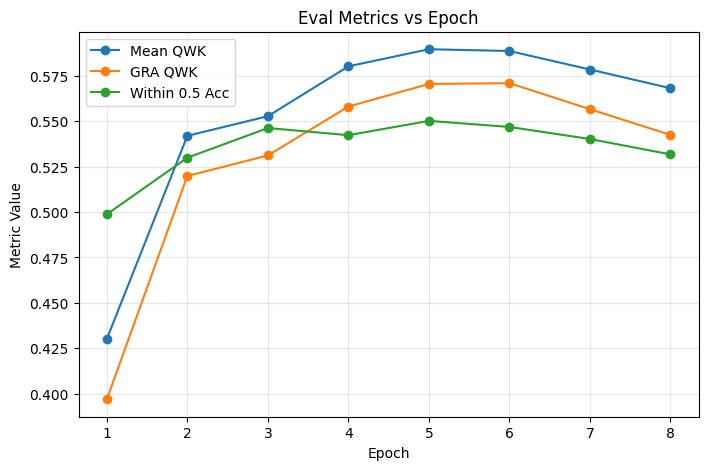

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# lấy log
log_history = trainer.state.log_history
df = pd.DataFrame(log_history)

# chỉ lấy các dòng có evaluation
eval_df = df[df["eval_mean_qwk"].notna()].copy()

# giữ metric cần
eval_df = eval_df[
    ["epoch","eval_loss","eval_mean_qwk","eval_gra_qwk","eval_within_0.5_acc"]
]

print(eval_df)

plt.figure(figsize=(8,5))

plt.plot(eval_df["epoch"], eval_df["eval_mean_qwk"], marker="o", label="Mean QWK")
plt.plot(eval_df["epoch"], eval_df["eval_gra_qwk"], marker="o", label="GRA QWK")
plt.plot(eval_df["epoch"], eval_df["eval_within_0.5_acc"], marker="o", label="Within 0.5 Acc")

plt.xlabel("Epoch")
plt.ylabel("Metric Value")
plt.title("Eval Metrics vs Epoch")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
val_metrics = trainer.evaluate(tokenized_ds["validation"])
print("Validation metrics:", val_metrics)

if "test" in tokenized_ds:
    test_metrics = trainer.evaluate(tokenized_ds["test"], metric_key_prefix="test")
    print("Test metrics:", test_metrics)

Validation metrics: {'eval_loss': 0.006314292084425688, 'eval_mean_mae': 0.7942865788936615, 'eval_mean_qwk': 0.5925448224437015, 'eval_tr_qwk': 0.6084338584368774, 'eval_cc_qwk': 0.5849353063400641, 'eval_lr_qwk': 0.6160871207066421, 'eval_gra_qwk': 0.5607230042912226, 'eval_within_0.5_acc': 0.5601571946795647, 'eval_runtime': 70.2926, 'eval_samples_per_second': 11.765, 'eval_steps_per_second': 11.765, 'epoch': 5.0}


early stopping required metric_for_best_model, but did not find eval_mean_qwk so early stopping is disabled


Test metrics: {'test_loss': 0.006335214711725712, 'test_mean_mae': 0.7851751297712326, 'test_mean_qwk': 0.585465440080091, 'test_tr_qwk': 0.6217668499890523, 'test_cc_qwk': 0.5778539466013854, 'test_lr_qwk': 0.6056911172065045, 'test_gra_qwk': 0.536549846523422, 'test_within_0.5_acc': 0.5703502415458938, 'test_runtime': 71.3512, 'test_samples_per_second': 11.605, 'test_steps_per_second': 11.605, 'epoch': 5.0}


In [ ]:
trainer.save_model(f"{OUTPUT_DIR}/best_model")
tokenizer.save_pretrained(f"{OUTPUT_DIR}/best_model")

('./qwen25_3b_ielts_4criteria/best_model/tokenizer_config.json',
 './qwen25_3b_ielts_4criteria/best_model/chat_template.jinja',
 './qwen25_3b_ielts_4criteria/best_model/tokenizer.json')

In [ ]:
BEST_DIR = "/content/best_model"

trainer.save_model(BEST_DIR)
tokenizer.save_pretrained(BEST_DIR)

print("Best model saved to:", BEST_DIR)
!du -sh /content/best_model

Best model saved to: /content/best_model
5.8G	/content/best_model


In [19]:
import os
import gc
import torch

# Nếu muốn train tiếp thêm, tăng tổng số epoch lên
# Ví dụ trước đó đã train 3 epoch, giờ muốn train tới epoch 6:
trainer.args.num_train_epochs = 8

# Tự tìm checkpoint mới nhất trong OUTPUT_DIR
checkpoint_dirs = [
    os.path.join(OUTPUT_DIR, d)
    for d in os.listdir(OUTPUT_DIR)
    if d.startswith("checkpoint-") and os.path.isdir(os.path.join(OUTPUT_DIR, d))
]

if not checkpoint_dirs:
    raise ValueError(f"Không tìm thấy checkpoint nào trong {OUTPUT_DIR}")

latest_checkpoint = max(checkpoint_dirs, key=lambda x: int(x.split("-")[-1]))
print("Resuming from:", latest_checkpoint)

gc.collect()
torch.cuda.empty_cache()

train_result = trainer.train(resume_from_checkpoint=latest_checkpoint)

print("Resume train xong.")
print(train_result)

Resuming from: ./qwen25_3b_ielts_4criteria/checkpoint-6622


Epoch,Training Loss,Validation Loss,Mean Mae,Mean Qwk,Tr Qwk,Cc Qwk,Lr Qwk,Gra Qwk,Within 0.5 Acc
8,7.464059,1.138637,0.822703,0.568172,0.571604,0.574802,0.583815,0.542467,0.531741


Resume train xong.
TrainOutput(global_step=7568, training_loss=0.754908355043504, metrics={'train_runtime': 1556.6981, 'train_samples_per_second': 34.01, 'train_steps_per_second': 4.862, 'total_flos': 0.0, 'train_loss': 0.754908355043504, 'epoch': 8.0})


In [ ]:
!rm -rf ./qwen25_3b_ielts_4criteria/checkpoint-*

In [ ]:
!zip -r /content/best_model.zip /content/best_model

  adding: content/best_model/ (stored 0%)
  adding: content/best_model/tokenizer.json (deflated 81%)
  adding: content/best_model/training_args.bin (deflated 53%)
  adding: content/best_model/tokenizer_config.json (deflated 59%)
  adding: content/best_model/model.safetensors (deflated 20%)
  adding: content/best_model/chat_template.jinja (deflated 71%)


In [ ]:
import shutil

shutil.copy(
    "/content/best_model.zip",
    "/content/drive/MyDrive/best_model.zip"
)

print("Best model copied to Google Drive")

Best model copied to Google Drive


In [ ]:
import os
import json
import torch
import shutil

EXPORT_DIR = "/content/B4_light_best_model"
os.makedirs(EXPORT_DIR, exist_ok=True)

model.backbone.save_pretrained(EXPORT_DIR)
tokenizer.save_pretrained(EXPORT_DIR)

head_state = {
    "tr_mlp": model.tr_mlp.state_dict(),
    "cc_mlp": model.cc_mlp.state_dict(),
    "lr_mlp": model.lr_mlp.state_dict(),
    "gra_mlp": model.gra_mlp.state_dict(),
}
torch.save(head_state, os.path.join(EXPORT_DIR, "custom_heads.pt"))

export_meta = {
    "model_name": MODEL_NAME,
    "max_length": MAX_LENGTH,
    "head_dropout": HEAD_DROPOUT,

    "target_cols": TARGET_COLS,
    "num_bins": NUM_BINS,
    "num_thresholds": NUM_THRESHOLDS,
    "score_min": SCORE_MIN,
    "score_max": SCORE_MAX,
    "score_step": SCORE_STEP,

    "tr_feature_cols": TR_FEATURE_COLS,
    "cc_feature_cols": CC_FEATURE_COLS,
    "lr_feature_cols": LR_FEATURE_COLS,
    "gra_feature_cols": GRA_FEATURE_COLS,

    "tr_feat_mean": tr_feat_mean.tolist(),
    "tr_feat_std": tr_feat_std.tolist(),
    "cc_feat_mean": cc_feat_mean.tolist(),
    "cc_feat_std": cc_feat_std.tolist(),
    "lr_feat_mean": lr_feat_mean.tolist(),
    "lr_feat_std": lr_feat_std.tolist(),
    "gra_feat_mean": gra_feat_mean.tolist(),
    "gra_feat_std": gra_feat_std.tolist(),

    "criterion_weights": CRITERION_WEIGHTS,
    "bias_loss_weight": BIAS_LOSS_WEIGHT,

    "labels_scaled_to_1": False,
    "ordinal_loss_name": ORDINAL_LOSS_NAME,
    "prediction_space": "band_4_to_9_step_0.5",
}
with open(os.path.join(EXPORT_DIR, "export_meta.json"), "w", encoding="utf-8") as f:
    json.dump(export_meta, f, ensure_ascii=False, indent=2)

print("Exported light model to:", EXPORT_DIR)
!du -sh /content/B4_light_best_model

Exported light model to: /content/B2_light_best_model
28M	/content/B2_light_best_model


In [ ]:
!zip -r /content/B4_light_best_model.zip /content/B4_light_best_model
!cp /content/B4_light_best_model.zip /content/drive/MyDrive/
print("Copied /content/B4_light_best_model.zip to Google Drive")

  adding: content/B2_light_best_model/ (stored 0%)
  adding: content/B2_light_best_model/README.md (deflated 66%)
  adding: content/B2_light_best_model/tokenizer.json (deflated 81%)
  adding: content/B2_light_best_model/custom_heads.pt (deflated 8%)
  adding: content/B2_light_best_model/adapter_config.json (deflated 57%)
  adding: content/B2_light_best_model/tokenizer_config.json (deflated 59%)
  adding: content/B2_light_best_model/export_meta.json (deflated 53%)
  adding: content/B2_light_best_model/chat_template.jinja (deflated 71%)
  adding: content/B2_light_best_model/adapter_model.safetensors (deflated 8%)
Copied /content/B2_light_best_model.zip to Google Drive
